# Diabetes — Data Visualization & Analysis
This notebook visualizes the Pima Indians Diabetes dataset, including imputation checks.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

VIZ_DIR = os.path.join("visualizations", "diabetes")
os.makedirs(VIZ_DIR, exist_ok=True)

# Load cleaned and raw datasets
df_clean = pd.read_csv(os.path.join("processed_data", "cleaned_diabetes.csv"))

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_raw = pd.read_csv(os.path.join("Dataset minor", "pima-indians-diabetes.csv"), names=cols)

print("Cleaned data shape:", df_clean.shape)
df_clean.head()

Cleaned data shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,114.329400,90.661655,45.060740,132.068191,34.989564,0.135675,32,0
1,1,90.000000,62.000000,12.000000,43.000000,27.200000,0.580000,24,0
2,0,166.409277,87.863375,48.609462,138.910164,52.558254,0.985188,34,1
3,13,86.216171,81.753215,46.023124,200.712311,25.344156,0.435794,40,1
4,2,133.456243,58.823731,30.128761,282.325363,28.200972,0.725033,24,1


## 1. Outcome Class Distribution
Shows the distribution of Non-Diabetic (`0`) vs Diabetic (`1`) individuals.

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_12568\3199069748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Outcome', data=df_clean, palette=['#27ae60', '#e67e22'])


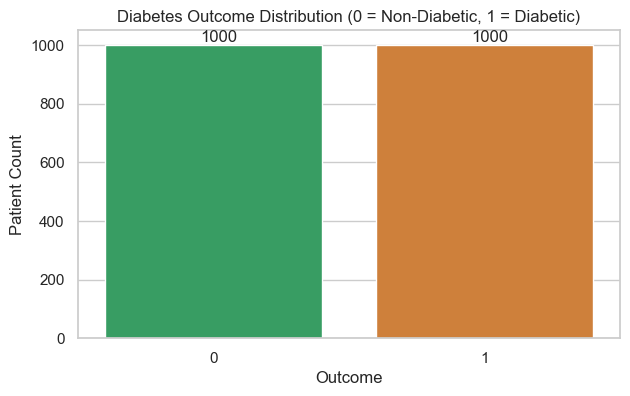

In [2]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='Outcome', data=df_clean, palette=['#27ae60', '#e67e22'])
plt.title("Diabetes Outcome Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.xlabel("Outcome")
plt.ylabel("Patient Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

plt.savefig(os.path.join(VIZ_DIR, "01_outcome_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 2. Imputation Validation: Before vs After
Verifies that replacing biologically impossible 0s with class medians restored natural distributions for Insulin and SkinThickness.

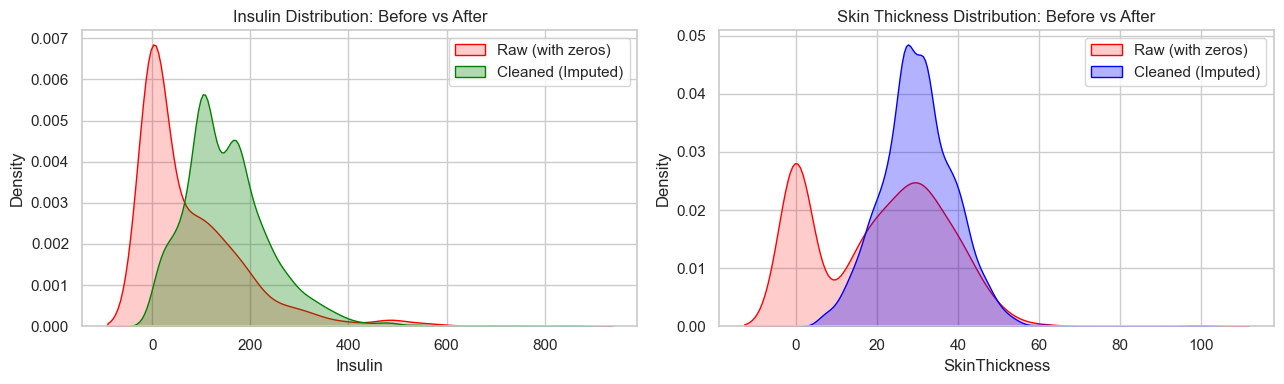

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Insulin Comparison
sns.kdeplot(df_raw['Insulin'], ax=axes[0], label='Raw (with zeros)', color='red', fill=True, alpha=0.2)
sns.kdeplot(df_clean['Insulin'], ax=axes[0], label='Cleaned (Imputed)', color='green', fill=True, alpha=0.3)
axes[0].set_title("Insulin Distribution: Before vs After")
axes[0].legend()

# SkinThickness Comparison
sns.kdeplot(df_raw['SkinThickness'], ax=axes[1], label='Raw (with zeros)', color='red', fill=True, alpha=0.2)
sns.kdeplot(df_clean['SkinThickness'], ax=axes[1], label='Cleaned (Imputed)', color='blue', fill=True, alpha=0.3)
axes[1].set_title("Skin Thickness Distribution: Before vs After")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "02_imputation_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap
Examines relationships between diabetes indicators.

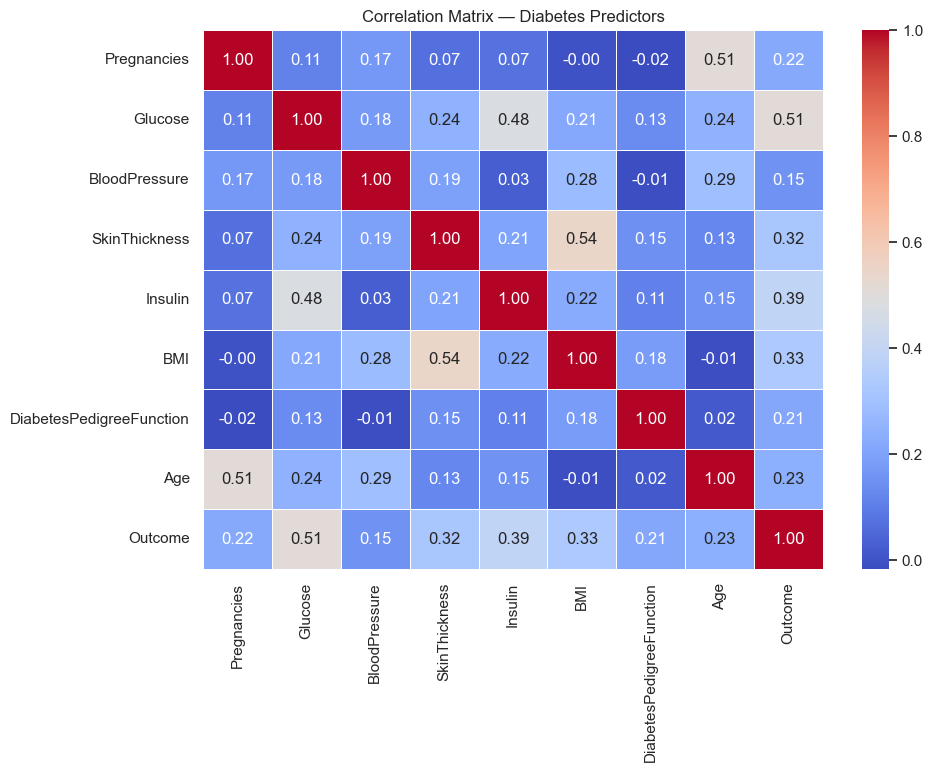

In [4]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix — Diabetes Predictors")
plt.savefig(os.path.join(VIZ_DIR, "03_diabetes_correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Glucose vs Insulin Scatter Plot
Shows metabolic coupling and insulin resistance in diabetic patients.

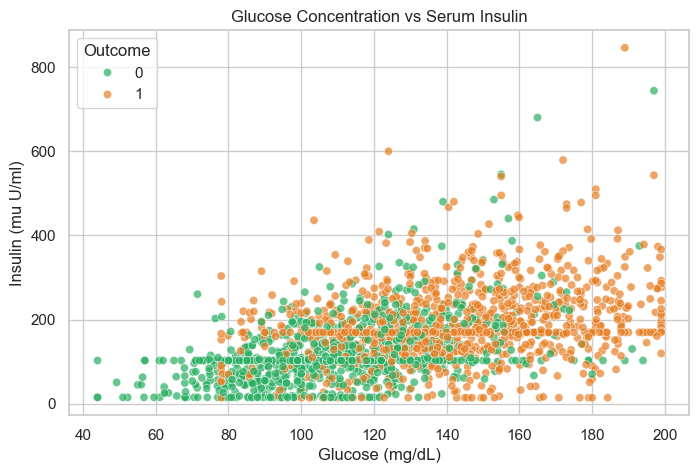

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Glucose', y='Insulin', hue='Outcome', data=df_clean, palette=['#27ae60', '#e67e22'], alpha=0.7)
plt.title("Glucose Concentration vs Serum Insulin")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Insulin (mu U/ml)")
plt.savefig(os.path.join(VIZ_DIR, "04_glucose_vs_insulin.png"), dpi=300, bbox_inches='tight')
plt.show()

## 5. BMI and Age Comparisons by Outcome
Boxplots comparing BMI and Age for diabetic vs non-diabetic groups.

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_12568\3711262799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=df_clean, ax=axes[0], palette=['#27ae60', '#e67e22'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_12568\3711262799.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_12568\3711262799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Age', data=df_clean, ax=axes[1], palette=['#27ae60', '#e67e22'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel

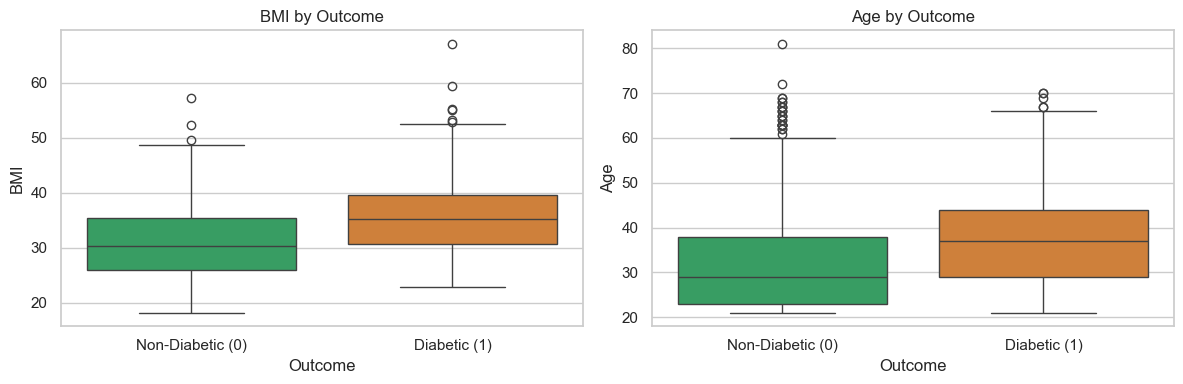

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Outcome', y='BMI', data=df_clean, ax=axes[0], palette=['#27ae60', '#e67e22'])
axes[0].set_title("BMI by Outcome")
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])

sns.boxplot(x='Outcome', y='Age', data=df_clean, ax=axes[1], palette=['#27ae60', '#e67e22'])
axes[1].set_title("Age by Outcome")
axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "05_bmi_and_age_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()